# M0 - Baseline regression lineaire (5 variables)

Objectif:
- entrainer une baseline lineaire sur `train.csv`
- utiliser uniquement les 5 variables retenues dans l'analyse
- comparer plusieurs strategies de preprocessing avec la meme CV
- selectionner la meilleure configuration puis generer une soumission Kaggle

Variables retenues:
`['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']`


In [57]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [58]:
# Chargement des donnees
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")
print(f"sample_submission shape: {sample_submission.shape}")


train shape: (1460, 81)
test shape: (1459, 80)
sample_submission shape: (1459, 2)


In [59]:
# Feature engineering: AgeAtSale = annee de vente - annee de construction
for df in [train_df, test_df]:
    df["AgeAtSale"] = df["YrSold"] - df["YearBuilt"]

features = ["OverallQual", "GrLivArea", "TotalBsmtSF", "AgeAtSale", "Neighborhood"]
target = "SalePrice"

print("Features baseline:", features)


Features baseline: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']


In [60]:
# Verification des valeurs manquantes pour les 5 variables
missing_train = train_df[features].isna().mean().mul(100).sort_values(ascending=False)
missing_test = test_df[features].isna().mean().mul(100).sort_values(ascending=False)

print("Missing % (train):")
print(missing_train)
print("\nMissing % (test):")
print(missing_test)


Missing % (train):
OverallQual     0.0
GrLivArea       0.0
TotalBsmtSF     0.0
AgeAtSale       0.0
Neighborhood    0.0
dtype: float64

Missing % (test):
TotalBsmtSF     0.06854
OverallQual     0.00000
GrLivArea       0.00000
AgeAtSale       0.00000
Neighborhood    0.00000
dtype: float64


In [61]:
# X / y
X_train = train_df[features].copy()
X_test = test_df[features].copy()

y_train = train_df[target].copy()
y_train_log = np.log1p(y_train)


## Protocole de comparaison

On garde le meme modele (`LinearRegression`) et les memes 5 variables.
Seul le preprocessing varie entre les experiences.


In [62]:
# CV fixe pour comparer toutes les experiences a armes egales

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

rmse_scorer = make_scorer(rmse, greater_is_better=False)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Groupes de colonnes (inchanges)
num_plain_median_features = ["OverallQual", "AgeAtSale"]
num_surface_median_features = ["GrLivArea"]
num_surface_zero_features = ["TotalBsmtSF"]
cat_features = ["Neighborhood"]


def make_numeric_pipeline(imputer_strategy="median", fill_value=None, log_transform=False, scale=False):
    steps = []
    if imputer_strategy == "constant":
        steps.append(("imputer", SimpleImputer(strategy="constant", fill_value=fill_value)))
    else:
        steps.append(("imputer", SimpleImputer(strategy=imputer_strategy)))

    if log_transform:
        steps.append(("log1p", FunctionTransformer(np.log1p, validate=False)))

    if scale:
        steps.append(("scaler", StandardScaler()))

    return Pipeline(steps=steps)


def build_preprocessor(config):
    use_scale = config["scale_numeric"]
    drop_first = config["drop_first"]
    log_surfaces = config["log_surfaces"]
    neighborhood_missing = config["neighborhood_missing"]

    cat_imputer = SimpleImputer(strategy="constant", fill_value="Missing")
    if neighborhood_missing == "most_frequent":
        cat_imputer = SimpleImputer(strategy="most_frequent")

    cat_encoder = OneHotEncoder(
        handle_unknown="ignore",
        drop="first" if drop_first else None,
    )

    transformers = [
        (
            "num_plain",
            make_numeric_pipeline(imputer_strategy="median", log_transform=False, scale=use_scale),
            num_plain_median_features,
        ),
        (
            "num_surface_median",
            make_numeric_pipeline(imputer_strategy="median", log_transform=log_surfaces, scale=use_scale),
            num_surface_median_features,
        ),
        (
            "num_surface_zero",
            make_numeric_pipeline(imputer_strategy="constant", fill_value=0, log_transform=log_surfaces, scale=use_scale),
            num_surface_zero_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", cat_imputer),
                    ("onehot", cat_encoder),
                ]
            ),
            cat_features,
        ),
    ]

    return ColumnTransformer(transformers=transformers)


def build_pipeline(config):
    preprocessor = build_preprocessor(config)
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression()),
        ]
    )


## Experiences de preprocessing


In [63]:
experiment_configs = [
    {
        "name": "E0_baseline",
        "scale_numeric": False,
        "drop_first": False,
        "log_surfaces": False,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E1_drop_first",
        "scale_numeric": False,
        "drop_first": True,
        "log_surfaces": False,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E2_scale_numeric",
        "scale_numeric": True,
        "drop_first": False,
        "log_surfaces": False,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E3_log_surfaces",
        "scale_numeric": False,
        "drop_first": False,
        "log_surfaces": True,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E4_log_surfaces_scale",
        "scale_numeric": True,
        "drop_first": False,
        "log_surfaces": True,
        "neighborhood_missing": "missing",
    },
    {
        "name": "E5_neighborhood_mode",
        "scale_numeric": False,
        "drop_first": False,
        "log_surfaces": False,
        "neighborhood_missing": "most_frequent",
    },
]

results = []
for cfg in experiment_configs:
    pipeline = build_pipeline(cfg)

    fold_rmse_log = []
    fold_mae_price = []
    fold_rmsle_price = []
    fold_overpred_pct = []

    for train_idx, val_idx in cv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr_log = y_train_log.iloc[train_idx]
        y_val_log = y_train_log.iloc[val_idx]
        y_val_price = y_train.iloc[val_idx]

        model_fold = clone(pipeline)
        model_fold.fit(X_tr, y_tr_log)

        pred_val_log = model_fold.predict(X_val)
        pred_val_price = np.expm1(pred_val_log)
        pred_val_price = np.clip(pred_val_price, a_min=0, a_max=None)

        residual_price = pred_val_price - y_val_price.to_numpy()
        overpred_rate = (residual_price > 0).mean() * 100

        fold_rmse_log.append(rmse(y_val_log, pred_val_log))
        fold_mae_price.append(mean_absolute_error(y_val_price, pred_val_price))
        fold_rmsle_price.append(rmsle(y_val_price, pred_val_price))
        fold_overpred_pct.append(overpred_rate)

    results.append(
        {
            "config": cfg["name"],
            "cv_rmse_log_mean": np.mean(fold_rmse_log),
            "cv_rmse_log_std": np.std(fold_rmse_log),
            "cv_mae_price_mean": np.mean(fold_mae_price),
            "cv_mae_price_std": np.std(fold_mae_price),
            "cv_rmsle_price_mean": np.mean(fold_rmsle_price),
            "cv_rmsle_price_std": np.std(fold_rmsle_price),
            "cv_overpred_pct_mean": np.mean(fold_overpred_pct),
            "cv_overpred_pct_std": np.std(fold_overpred_pct),
            "fold_rmse_log": np.round(fold_rmse_log, 5).tolist(),
        }
    )

results_df = pd.DataFrame(results)


## Classement Kaggle (RMSE log)


In [64]:
kaggle_rank_df = (
    results_df
    .sort_values(["cv_rmse_log_mean", "cv_rmse_log_std"])
    .reset_index(drop=True)
)

print("Classement Kaggle (plus bas = meilleur):")
display(kaggle_rank_df[["config", "cv_rmse_log_mean", "cv_rmse_log_std", "fold_rmse_log"]])

best_kaggle_config = kaggle_rank_df.iloc[0]["config"]
print(f"Gagnant classement Kaggle: {best_kaggle_config}")


Classement Kaggle (plus bas = meilleur):


,config,cv_rmse_log_mean,cv_rmse_log_std,fold_rmse_log
0,E4_log_surfaces_scale,0.162856,0.009543,"[0.16373, 0.1488, 0.17781, 0.16595, 0.15798]"
1,E3_log_surfaces,0.162857,0.009545,"[0.16373, 0.1488, 0.17782, 0.16596, 0.15797]"
2,E2_scale_numeric,0.171051,0.028530,"[0.16121, 0.14806, 0.2273, 0.16111, 0.15758]"
3,E0_baseline,0.171111,0.028554,"[0.16099, 0.14821, 0.22744, 0.16114, 0.15779]"
4,E5_neighborhood_mode,0.171111,0.028554,"[0.16099, 0.14821, 0.22744, 0.16114, 0.15779]"
5,E1_drop_first,0.171214,0.028474,"[0.16128, 0.14834, 0.22737, 0.16117, 0.1579]"


Gagnant classement Kaggle: E4_log_surfaces_scale


## Classement metier banque (ecart de prix reel)

Lecture des colonnes:
- `config`: nom de l'experience de preprocessing testee.
- `cv_mae_price_mean`: erreur absolue moyenne en prix reel en euros (plus bas = meilleur pour le metier).
- `cv_rmsle_price_mean`: erreur relative en %, capture l'ecart proportionnel (plus bas = meilleur).
- `cv_overpred_pct_mean`: pourcentage moyen de dossiers sur-predits (`prediction > reel`, risque critique).


In [65]:
business_rank_df = (
    results_df
    .sort_values(["cv_mae_price_mean", "cv_overpred_pct_mean", "cv_rmsle_price_mean"])
    .reset_index(drop=True)
)

print("Classement metier (priorite MAE + sur-prediction basse):")
display(
    business_rank_df[
        [
            "config",
            "cv_mae_price_mean",
            "cv_rmsle_price_mean",
            "cv_overpred_pct_mean",
        ]
    ]
)

best_business_config = business_rank_df.iloc[0]["config"]
print(f"Gagnant classement metier: {best_business_config}")


Classement metier (priorite MAE + sur-prediction basse):


,config,cv_mae_price_mean,cv_rmsle_price_mean,cv_overpred_pct_mean
0,E4_log_surfaces_scale,21164.406249,0.162856,47.808219
1,E3_log_surfaces,21164.626288,0.162857,47.808219
2,E2_scale_numeric,21336.179138,0.171051,46.712329
3,E0_baseline,21338.610500,0.171111,46.917808
4,E5_neighborhood_mode,21338.610500,0.171111,46.917808
5,E1_drop_first,21364.512036,0.171214,46.712329


Gagnant classement metier: E4_log_surfaces_scale


## Decision finale: classement global pondere


In [66]:
# Contexte banque: priorite au metier (MAE + sur-prediction basse)
w_kaggle = 0.2
w_mae_business = 0.6
w_overpred_business = 0.2

decision_df = results_df.copy()
decision_df["rank_kaggle"] = decision_df["cv_rmse_log_mean"].rank(method="min", ascending=True)
decision_df["rank_business_mae"] = decision_df["cv_mae_price_mean"].rank(method="min", ascending=True)
decision_df["rank_business_overpred"] = decision_df["cv_overpred_pct_mean"].rank(method="min", ascending=True)

decision_df["rank_global_weighted"] = (
    w_kaggle * decision_df["rank_kaggle"]
    + w_mae_business * decision_df["rank_business_mae"]
    + w_overpred_business * decision_df["rank_business_overpred"]
)

decision_df = decision_df.sort_values(
    ["rank_global_weighted", "cv_mae_price_mean", "cv_overpred_pct_mean", "cv_rmse_log_mean"]
).reset_index(drop=True)

print("Tableau de decision global:")
display(
    decision_df[
        [
            "config",
            "cv_rmse_log_mean",
            "cv_mae_price_mean",
            "cv_rmsle_price_mean",
            "cv_overpred_pct_mean",
            "rank_kaggle",
            "rank_business_mae",
            "rank_business_overpred",
            "rank_global_weighted",
        ]
    ]
)

best_global_config = decision_df.iloc[0]["config"]
print(f"Gagnant Kaggle : {best_kaggle_config}")
print(f"Gagnant metier : {best_business_config}")
print(f"Gagnant global : {best_global_config}")

best_config = next(cfg for cfg in experiment_configs if cfg["name"] == best_global_config)
print("Configuration retenue pour le fit final:")
print(best_config)


Tableau de decision global:


,config,cv_rmse_log_mean,cv_mae_price_mean,cv_rmsle_price_mean,cv_overpred_pct_mean,rank_kaggle,rank_business_mae,rank_business_overpred,rank_global_weighted
0,E4_log_surfaces_scale,0.162856,21164.406249,0.162856,47.808219,1.0,1.0,5.0,1.8
1,E3_log_surfaces,0.162857,21164.626288,0.162857,47.808219,2.0,2.0,5.0,2.6
2,E2_scale_numeric,0.171051,21336.179138,0.171051,46.712329,3.0,3.0,1.0,2.6
3,E0_baseline,0.171111,21338.610500,0.171111,46.917808,4.0,4.0,3.0,3.8
4,E5_neighborhood_mode,0.171111,21338.610500,0.171111,46.917808,4.0,4.0,3.0,3.8
5,E1_drop_first,0.171214,21364.512036,0.171214,46.712329,6.0,6.0,1.0,5.0


Gagnant Kaggle : E4_log_surfaces_scale
Gagnant metier : E4_log_surfaces_scale
Gagnant global : E4_log_surfaces_scale
Configuration retenue pour le fit final:
{'name': 'E4_log_surfaces_scale', 'scale_numeric': True, 'drop_first': False, 'log_surfaces': True, 'neighborhood_missing': 'missing'}


## Diagnostic visuel du modele gagnant (train, out-of-fold)

On trace `valeur reelle` (x) vs `valeur predite` (y) pour la configuration gagnante,
avec des predictions out-of-fold (meme CV) pour eviter la fuite de donnees.


OOF MAE (prix reel): 21164.41
OOF RMSE (prix reel): 34262.45
OOF RMSLE (erreur relative): 0.1631


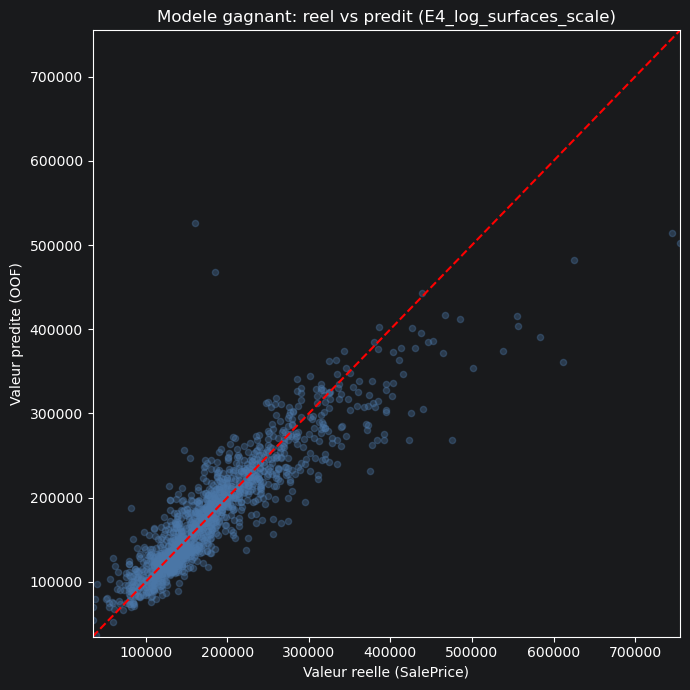

In [67]:
oof_pred_log = np.zeros(len(X_train), dtype=float)

for train_idx, val_idx in cv.split(X_train):
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr_log = y_train_log.iloc[train_idx]

    model_fold = clone(build_pipeline(best_config))
    model_fold.fit(X_tr, y_tr_log)
    oof_pred_log[val_idx] = model_fold.predict(X_val)

oof_pred_price = np.expm1(oof_pred_log)
oof_pred_price = np.clip(oof_pred_price, a_min=0, a_max=None)

oof_mae = mean_absolute_error(y_train, oof_pred_price)
oof_rmse = rmse(y_train, oof_pred_price)
oof_rmsle = rmsle(y_train, oof_pred_price)
print(f"OOF MAE (prix reel): {oof_mae:.2f}")
print(f"OOF RMSE (prix reel): {oof_rmse:.2f}")
print(f"OOF RMSLE (erreur relative): {oof_rmsle:.4f}")

min_axis = min(float(y_train.min()), float(oof_pred_price.min()))
max_axis = max(float(y_train.max()), float(oof_pred_price.max()))

plt.figure(figsize=(7, 7))
plt.scatter(y_train, oof_pred_price, alpha=0.35, s=20, color="#4C78A8")
plt.plot([min_axis, max_axis], [min_axis, max_axis], color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Valeur reelle (SalePrice)")
plt.ylabel("Valeur predite (OOF)")
plt.title(f"Modele gagnant: reel vs predit ({best_global_config})")
plt.xlim(min_axis, max_axis)
plt.ylim(min_axis, max_axis)
plt.tight_layout()
plt.show()


# Entrainement final

In [68]:
# Entrainement final avec la meilleure configuration globale
best_pipeline = build_pipeline(best_config)
best_pipeline.fit(X_train, y_train_log)

# Prediction sur test puis retour a l'echelle du prix
test_pred_log = best_pipeline.predict(X_test)
test_pred = np.expm1(test_pred_log)

# Securite numerique: eviter des valeurs negatives dues a l'approximation lineaire
test_pred = np.clip(test_pred, a_min=0, a_max=None)

print("Predictions test - min / max:", float(test_pred.min()), float(test_pred.max()))


Predictions test - min / max: 46902.12416991126 473988.6385390454


In [69]:
# Creation du fichier de soumission Kaggle
submission = sample_submission.copy()
submission["SalePrice"] = test_pred

output_path = BASE_DIR / f"submission_m0_linear_{best_global_config}.csv"
submission.to_csv(output_path, index=False)

print(f"Submission ecrite: {output_path}")
submission.head()


Submission ecrite: submission_m0_linear_E4_log_surfaces_scale.csv


,Id,SalePrice
0,1461,118603.225900
1,1462,156676.815262
2,1463,164349.867613
3,1464,179771.226989
4,1465,239982.883317
